# Notebook 04 — Fusion U-Net Evaluation

Thorough evaluation of the dual-encoder cross-attention fusion model (S1 + S2).

**Sections:**
1. Load best checkpoint
2. Training curves
3. Test set metrics vs baselines
4. Per-chip IoU distribution
5. Visual prediction gallery (best / worst / typical chips)
6. Error analysis — where does the model fail?
7. S1 vs S2 contribution (qualitative)

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import rasterio

sys.path.insert(0, str(Path('..').resolve()))

from src.models.fusion_unet import FusionUNet
from src.data.dataset import Sen1Floods11MultiModal
from src.utils.metrics import compute_metrics, MetricAccumulator

# Paths
DATA_ROOT   = Path('F:/Sen1Flood1/v1.1/data/flood_events/HandLabeled')
SPLITS_DIR  = Path('F:/Sen1Flood1/v1.1/splits/flood_handlabeled')
CKPT_PATH   = Path('../results/checkpoints/fusion_unet_best.pt')
HISTORY_PATH = Path('../results/logs/fusion_unet_history.json')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Checkpoint exists: {CKPT_PATH.exists()}')

Device: cuda
Checkpoint exists: True


## 1. Load Best Checkpoint

In [2]:
model = FusionUNet(s1_channels=2, s2_channels=13, num_classes=2).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded epoch {ckpt['epoch']}  |  Val IoU: {ckpt['val_iou']:.4f}  |  Val Dice: {ckpt['val_dice']:.4f}")

Loaded epoch 28  |  Val IoU: 0.7495  |  Val Dice: 0.8568


## 2. Training Curves

In [3]:
if not HISTORY_PATH.exists():
    print(f'No history file — training was stopped early.')
    print(f'Best checkpoint: epoch {ckpt["epoch"]}, Val IoU {ckpt["val_iou"]:.4f}, Val Dice {ckpt["val_dice"]:.4f}')
else:
    with open(HISTORY_PATH) as f:
        history = json.load(f)

    epochs     = [h['epoch'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h['val_loss'] for h in history]
    val_iou    = [h['val_iou'] for h in history]
    val_dice   = [h['val_dice'] for h in history]
    best_epoch = max(history, key=lambda h: h['val_iou'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_loss, label='Train Loss', color='steelblue')
    axes[0].plot(epochs, val_loss,   label='Val Loss',   color='coral')
    axes[0].axvline(best_epoch['epoch'], color='green', linestyle='--', alpha=0.6, label=f"Best (ep {best_epoch['epoch']})")
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Fusion U-Net — Loss Curves')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, val_iou,  label='Val IoU',  color='mediumseagreen')
    axes[1].plot(epochs, val_dice, label='Val Dice', color='mediumpurple')
    axes[1].axhline(0.638, color='gray', linestyle=':', alpha=0.8, label='FCN baseline IoU 0.638')
    axes[1].axvline(best_epoch['epoch'], color='green', linestyle='--', alpha=0.6)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].set_title('Fusion U-Net — Validation Metrics')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../results/figures/fusion_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Best epoch: {best_epoch['epoch']}  |  Val IoU: {best_epoch['val_iou']:.4f}  |  Val Dice: {best_epoch['val_dice']:.4f}")

No history file — training was stopped early.
Best checkpoint: epoch 28, Val IoU 0.7495, Val Dice 0.8568


## 3. Test Set Metrics vs Baselines

In [4]:
def evaluate_split(split_name):
    split_map = {
        'train': 'flood_train_data.csv',
        'val':   'flood_valid_data.csv',
        'test':  'flood_test_data.csv',
    }
    dataset = Sen1Floods11MultiModal(
        split_csv=SPLITS_DIR / split_map[split_name],
        s1_dir=DATA_ROOT / 'S1Hand',
        s2_dir=DATA_ROOT / 'S2Hand',
        label_dir=DATA_ROOT / 'LabelHand',
        crop_size=None, augment=False, normalize=True,
    )
    acc = MetricAccumulator()
    per_chip = []

    for idx in range(len(dataset)):
        s1, s2, label = dataset[idx]
        with torch.no_grad():
            out = model(s1.unsqueeze(0).to(device), s2.unsqueeze(0).to(device))
        pred = torch.argmax(out, dim=1).squeeze(0).cpu().numpy()
        m = compute_metrics(pred, label.numpy(), ignore_index=255)
        m['file'] = dataset.samples[idx][0]
        per_chip.append(m)
        acc.update(pred, label.numpy(), ignore_index=255)

    return acc.compute(), per_chip

print('Evaluating on test set...')
test_agg, test_chips = evaluate_split('test')

# Comparison table
baselines = {
    'Otsu (S1 VH)':        {'iou': 0.230, 'dice': None,  'precision': None,  'recall': None},
    'FCN-ResNet50 (S1)':   {'iou': 0.638, 'dice': 0.779, 'precision': 0.746, 'recall': 0.815},
    'Fusion U-Net (S1+S2)': test_agg,
}

print(f"\n{'Model':<25} {'IoU':>6} {'Dice':>6} {'Prec':>6} {'Rec':>6}")
print('-' * 55)
for name, m in baselines.items():
    iou  = f"{m['iou']:.4f}" if m['iou']  is not None else '  -   '
    dice = f"{m['dice']:.4f}" if m['dice'] is not None else '  -   '
    prec = f"{m['precision']:.4f}" if m.get('precision') is not None else '  -   '
    rec  = f"{m['recall']:.4f}" if m.get('recall')    is not None else '  -   '
    print(f"{name:<25} {iou:>6} {dice:>6} {prec:>6} {rec:>6}")

Evaluating on test set...

Model                        IoU   Dice   Prec    Rec
-------------------------------------------------------
Otsu (S1 VH)              0.2300   -      -      -   
FCN-ResNet50 (S1)         0.6380 0.7790 0.7460 0.8150
Fusion U-Net (S1+S2)      0.7649 0.8668 0.8139 0.9271


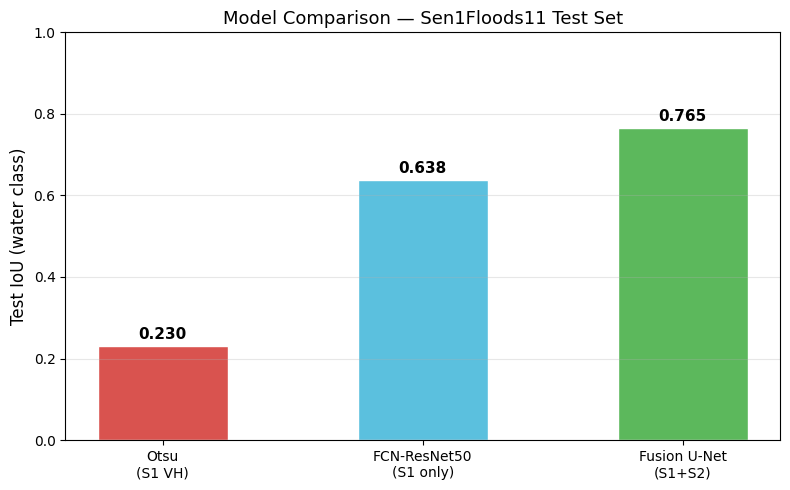

In [5]:
# Bar chart comparison
models_  = ['Otsu\n(S1 VH)', 'FCN-ResNet50\n(S1 only)', 'Fusion U-Net\n(S1+S2)']
ious     = [0.230, 0.638, test_agg['iou']]
colors   = ['#d9534f', '#5bc0de', '#5cb85c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_, ious, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, ious):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Test IoU (water class)', fontsize=12)
ax.set_title('Model Comparison — Sen1Floods11 Test Set', fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/fusion_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Chip IoU Distribution

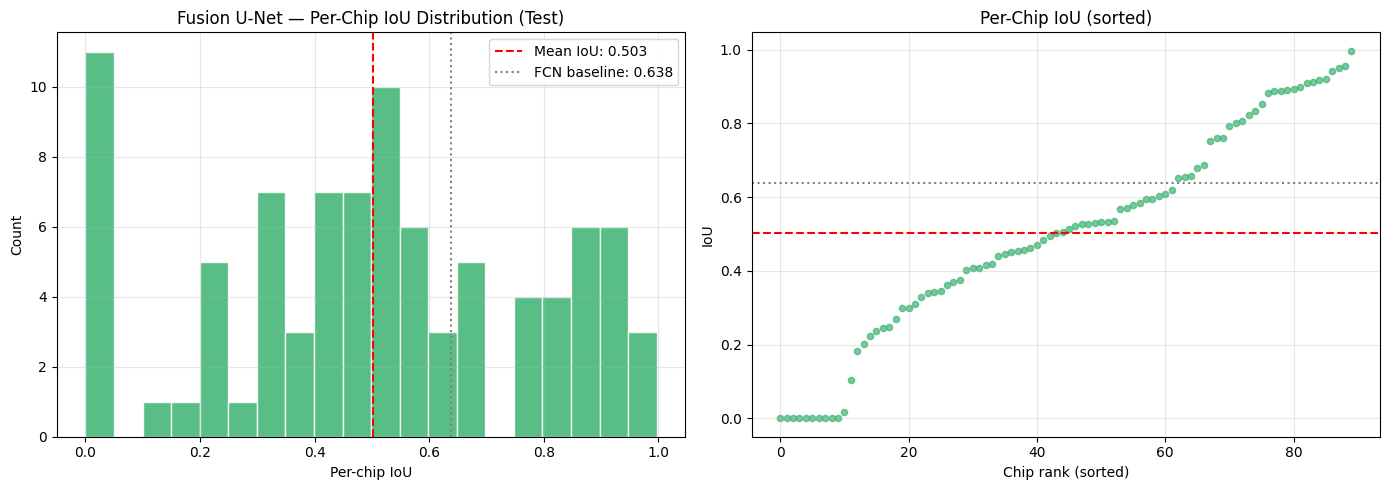

Mean IoU: 0.5026  |  Median: 0.5097
IoU > 0.5: 47/90 chips
IoU = 0  : 9/90 chips (no water or total failure)


In [6]:
chip_ious = [c['iou'] for c in test_chips]
chip_names = [Path(c['file']).stem.replace('_S1Hand','') for c in test_chips]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(chip_ious, bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(chip_ious), color='red', linestyle='--', label=f'Mean IoU: {np.mean(chip_ious):.3f}')
axes[0].axvline(0.638, color='gray', linestyle=':', label='FCN baseline: 0.638')
axes[0].set_xlabel('Per-chip IoU'); axes[0].set_ylabel('Count')
axes[0].set_title('Fusion U-Net — Per-Chip IoU Distribution (Test)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Sorted strip
sorted_ious = sorted(chip_ious)
axes[1].scatter(range(len(sorted_ious)), sorted_ious, s=20, color='mediumseagreen', alpha=0.7)
axes[1].axhline(np.mean(sorted_ious), color='red', linestyle='--')
axes[1].axhline(0.638, color='gray', linestyle=':')
axes[1].set_xlabel('Chip rank (sorted)'); axes[1].set_ylabel('IoU')
axes[1].set_title('Per-Chip IoU (sorted)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/fusion_per_chip_iou.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean IoU: {np.mean(chip_ious):.4f}  |  Median: {np.median(chip_ious):.4f}")
print(f"IoU > 0.5: {sum(i > 0.5 for i in chip_ious)}/{len(chip_ious)} chips")
print(f"IoU = 0  : {sum(i == 0 for i in chip_ious)}/{len(chip_ious)} chips (no water or total failure)")

## 5. Visual Prediction Gallery

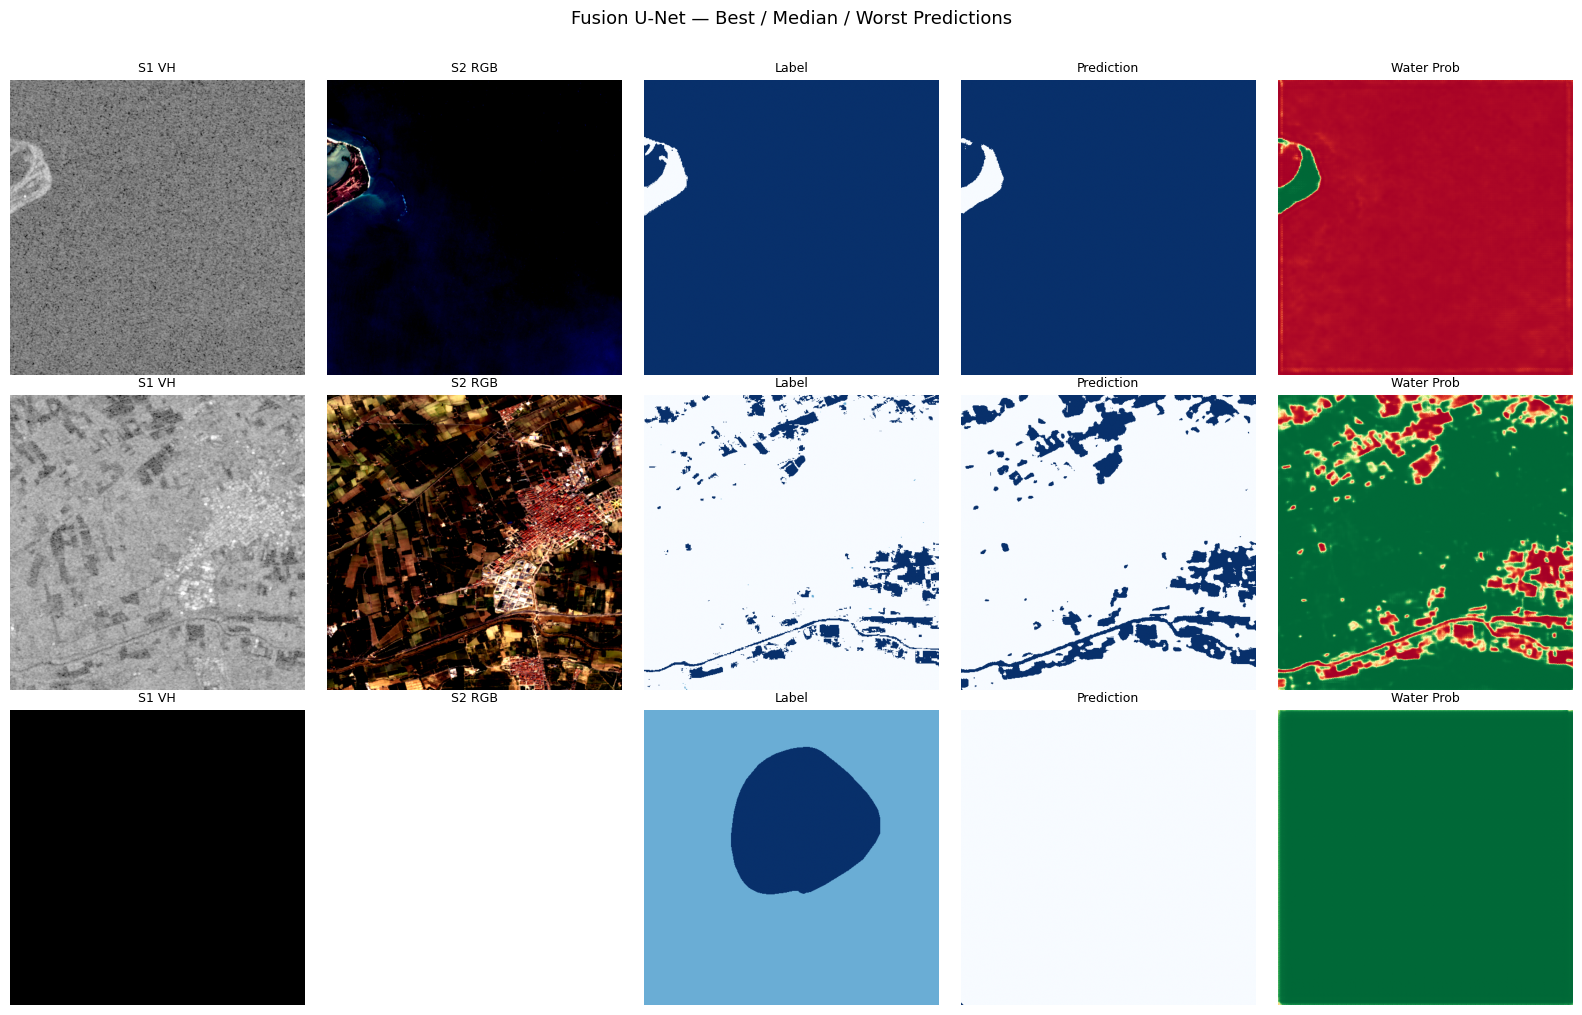

In [7]:
def get_prediction(dataset, idx):
    s1, s2, label = dataset[idx]
    with torch.no_grad():
        out = model(s1.unsqueeze(0).to(device), s2.unsqueeze(0).to(device))
    pred = torch.argmax(out, dim=1).squeeze(0).cpu().numpy()
    prob = torch.softmax(out, dim=1)[0, 1].cpu().numpy()  # water probability
    return s1.numpy(), s2.numpy(), label.numpy(), pred, prob

def show_chip(ax_s1, ax_s2_rgb, ax_label, ax_pred, ax_prob, s1, s2, label, pred, prob, title):
    # S1 VH (band 1, after normalization — unnormalize for display)
    vh = s1[1]; vh = (vh - vh.min()) / (vh.max() - vh.min() + 1e-8)
    ax_s1.imshow(vh, cmap='gray'); ax_s1.set_title('S1 VH', fontsize=9); ax_s1.axis('off')

    # S2 RGB (B4=Red, B3=Green, B2=Blue → bands 3,2,1 in 0-indexed)
    rgb = np.stack([s2[3], s2[2], s2[1]], axis=-1)
    rgb = np.clip(rgb / (rgb.max() + 1e-8) * 3, 0, 1)  # brighten
    ax_s2_rgb.imshow(rgb); ax_s2_rgb.set_title('S2 RGB', fontsize=9); ax_s2_rgb.axis('off')

    # Label
    lbl_disp = np.where(label == 255, 0.5, label.astype(float))
    ax_label.imshow(lbl_disp, cmap='Blues', vmin=0, vmax=1)
    ax_label.set_title('Label', fontsize=9); ax_label.axis('off')

    # Prediction
    ax_pred.imshow(pred, cmap='Blues', vmin=0, vmax=1)
    ax_pred.set_title('Prediction', fontsize=9); ax_pred.axis('off')

    # Probability map
    im = ax_prob.imshow(prob, cmap='RdYlGn_r', vmin=0, vmax=1)
    ax_prob.set_title('Water Prob', fontsize=9); ax_prob.axis('off')

    ax_s1.set_ylabel(title, fontsize=8, rotation=90, labelpad=4)

# Select best, median, worst chips (with some water)
water_chips = [(c['iou'], i) for i, c in enumerate(test_chips) if c['tp'] + c['fn'] > 500]
water_chips.sort()
worst_idx  = water_chips[0][1]
median_idx = water_chips[len(water_chips)//2][1]
best_idx   = water_chips[-1][1]

dataset_test = Sen1Floods11MultiModal(
    split_csv=SPLITS_DIR / 'flood_test_data.csv',
    s1_dir=DATA_ROOT / 'S1Hand', s2_dir=DATA_ROOT / 'S2Hand', label_dir=DATA_ROOT / 'LabelHand',
    crop_size=None, augment=False, normalize=True,
)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for row, (idx, label_str) in enumerate([
    (best_idx,   f'Best  (IoU={test_chips[best_idx]["iou"]:.3f})'),
    (median_idx, f'Median (IoU={test_chips[median_idx]["iou"]:.3f})'),
    (worst_idx,  f'Worst (IoU={test_chips[worst_idx]["iou"]:.3f})'),
]):
    s1, s2, label, pred, prob = get_prediction(dataset_test, idx)
    show_chip(axes[row,0], axes[row,1], axes[row,2], axes[row,3], axes[row,4],
              s1, s2, label, pred, prob, label_str)

fig.suptitle('Fusion U-Net — Best / Median / Worst Predictions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/fusion_prediction_gallery.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error Analysis — FP and FN Maps

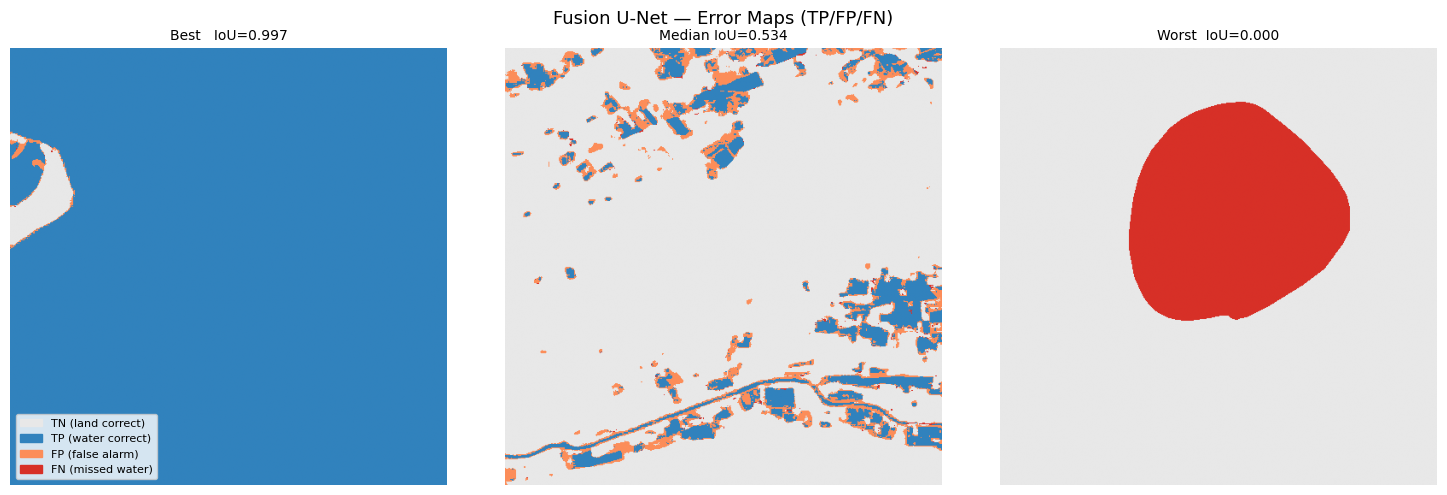

In [8]:
# Show error map for a few representative chips
def plot_error_map(idx, title):
    s1, s2, label, pred, prob = get_prediction(dataset_test, idx)
    valid = label != 255
    error = np.zeros_like(pred, dtype=np.uint8)
    error[(pred == 1) & (label == 1) & valid] = 1   # TP — correct water
    error[(pred == 1) & (label == 0) & valid] = 2   # FP — false alarm
    error[(pred == 0) & (label == 1) & valid] = 3   # FN — missed water
    error[(pred == 0) & (label == 0) & valid] = 0   # TN — correct land

    cmap = plt.cm.colors.ListedColormap(['#e8e8e8', '#3182bd', '#fc8d59', '#d73027'])
    import matplotlib.patches as mpatches
    patches = [
        mpatches.Patch(color='#e8e8e8', label='TN (land correct)'),
        mpatches.Patch(color='#3182bd', label='TP (water correct)'),
        mpatches.Patch(color='#fc8d59', label='FP (false alarm)'),
        mpatches.Patch(color='#d73027', label='FN (missed water)'),
    ]
    return error, cmap, patches, title

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx_str in zip(axes, [
    (best_idx,   f'Best   IoU={test_chips[best_idx]["iou"]:.3f}'),
    (median_idx, f'Median IoU={test_chips[median_idx]["iou"]:.3f}'),
    (worst_idx,  f'Worst  IoU={test_chips[worst_idx]["iou"]:.3f}'),
]):
    idx, title = idx_str
    error, cmap, patches, title = plot_error_map(idx, title)
    ax.imshow(error, cmap=cmap, vmin=0, vmax=3)
    ax.set_title(title, fontsize=10); ax.axis('off')

axes[0].legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.8)
fig.suptitle('Fusion U-Net — Error Maps (TP/FP/FN)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/fusion_error_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [9]:
print('=' * 55)
print('  FUSION U-NET — FINAL TEST RESULTS')
print('=' * 55)
for k in ['iou', 'dice', 'precision', 'recall', 'f1', 'accuracy']:
    print(f'  {k:<12}: {test_agg[k]:.4f}')
print()
print(f'  TP: {test_agg["tp"]:,}  FP: {test_agg["fp"]:,}')
print(f'  TN: {test_agg["tn"]:,}  FN: {test_agg["fn"]:,}')
print()
print(f'  Improvement over FCN baseline (IoU 0.638):')
delta = test_agg['iou'] - 0.638
pct   = delta / 0.638 * 100
print(f'  Δ IoU = {delta:+.4f}  ({pct:+.1f}%)')

  FUSION U-NET — FINAL TEST RESULTS
  iou         : 0.7649
  dice        : 0.8668
  precision   : 0.8139
  recall      : 0.9271
  f1          : 0.8668
  accuracy    : 0.9644

  TP: 2,378,970  FP: 544,132
  TN: 17,407,134  FN: 187,131

  Improvement over FCN baseline (IoU 0.638):
  Δ IoU = +0.1269  (+19.9%)
